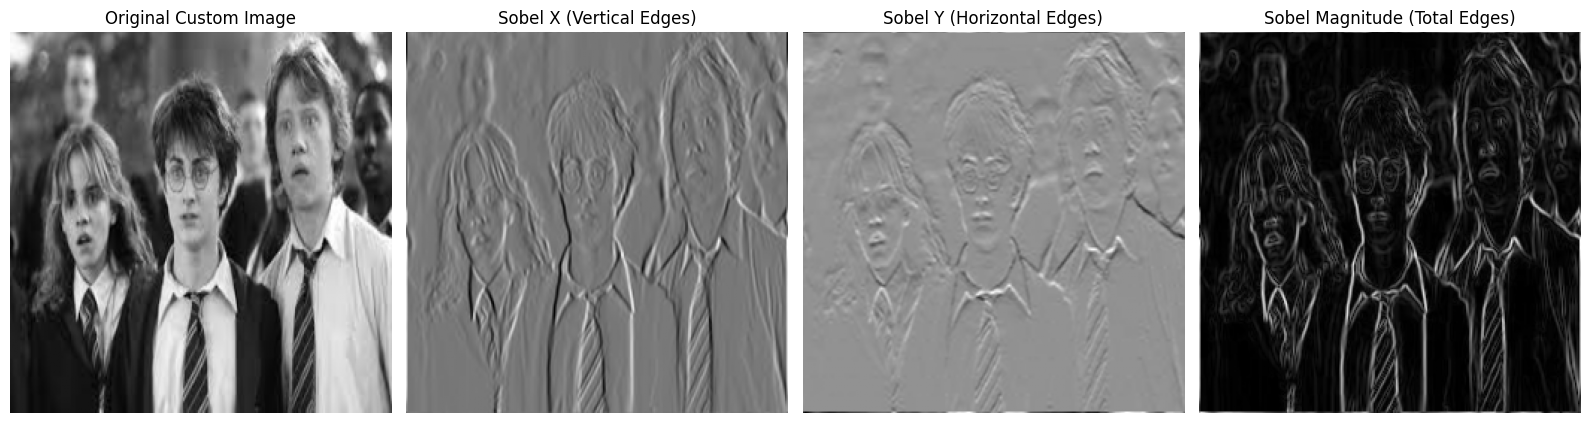

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

# Load and resize image
image_path = 'HP2.jpeg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Resize to a square power of 2 for optimal FFT performance
image = resize(image, (256, 256))
M, N = image.shape

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    
    # Shift before FFT to place (0,0) at top-left
    return fft2(ifftshift(padded)) 

# Compute FFT of image
F_image = fft2(image)

# FFT of centered Sobel filters
H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

# Multiply in the frequency domain
G_x = F_image * H_x
G_y = F_image * H_y

# Inverse FFT to get back to the spatial domain
grad_x = ifft2(G_x).real
grad_y = ifft2(G_y).real

# Compute the overall gradient magnitude
sobel_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Plot
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Custom Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(grad_x, cmap='gray')
plt.title('Sobel X (Vertical Edges)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(grad_y, cmap='gray')
plt.title('Sobel Y (Horizontal Edges)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Magnitude (Total Edges)')
plt.axis('off')

plt.tight_layout()
plt.show()